In [2]:
import pandas as pd

In [15]:
macro_training_data = pd.read_csv("macro_training_data_features.csv",parse_dates=["aligned_date"])
sentiment_training_data = pd.read_csv("sentiment_training_data_features.csv",parse_dates=["aligned_date"])
all_feature_data = pd.merge(
    sentiment_training_data, 
    macro_training_data, 
    on='aligned_date', 
    how='inner'
)
all_feature_data

,aligned_date,Pos_Score_30day_EMA,Neg_Score_30day_EMA,Neutrality_Ratio_30day_EMA,period_rolling_recession,recession,CPIAUCSL,PAYEMS,UNRATE,INDPRO,...,UMCSENT_MoM,UMCSENT_YoY,UNRATE_MoM_diff,UNRATE_YoY_diff,T10Y3M_MoM_diff,T10Y3M_YoY_diff,T10Y2Y_MoM_diff,T10Y2Y_YoY_diff,BAA10Y_MoM_diff,BAA10Y_YoY_diff
0,2008-03-01,0.091419,0.076210,0.802671,1.0,1.0,212.516,138102.0,4.9,114.2334,...,-0.062252,-0.231270,0.2,0.5,1.00,2.25,0.89,2.04,0.70,1.58
1,2008-04-01,0.086294,0.133178,0.751682,1.0,1.0,212.571,137993.0,4.8,113.6597,...,-0.018362,-0.242094,-0.1,0.3,0.39,2.38,-0.05,1.94,0.23,1.81
2,2008-05-01,0.102576,0.143538,0.737736,1.0,1.0,213.301,137846.0,5.1,112.1281,...,-0.099281,-0.353973,0.3,0.5,0.27,2.94,-0.35,1.57,-0.35,1.50
3,2008-06-01,0.100660,0.192518,0.694959,1.0,1.0,213.743,137818.0,5.0,111.1807,...,-0.044728,-0.323529,-0.1,0.5,-0.17,2.56,-0.08,1.33,-0.10,1.25
4,2008-07-01,0.102464,0.182724,0.699128,1.0,1.0,215.132,137754.0,5.5,110.9051,...,-0.056856,-0.352468,0.5,1.1,-0.08,2.37,-0.04,1.33,0.05,1.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2023-11-01,0.238531,0.333319,0.417078,0.0,0.0,307.481,156874.0,3.8,103.6115,...,-0.060383,0.065109,0.0,0.3,0.25,-0.59,0.25,0.22,0.07,-0.43
176,2023-12-01,0.248363,0.330789,0.426987,0.0,0.0,307.619,156923.0,3.9,102.7081,...,-0.039185,0.079225,0.1,0.2,-0.37,-0.39,-0.17,0.34,-0.18,-0.48
177,2024-01-01,0.250814,0.336532,0.425602,0.0,0.0,307.917,157087.0,3.7,102.6651,...,0.137031,0.167504,-0.2,0.0,-0.44,-0.98,0.01,0.18,-0.06,-0.38
178,2024-03-01,0.249285,0.334898,0.423904,0.0,0.0,309.685,157700.0,3.7,102.5739,...,0.133429,0.217257,0.0,0.2,0.32,-0.02,-0.04,0.30,-0.06,-0.35


Text(0, 0.5, 'Correlation Value')

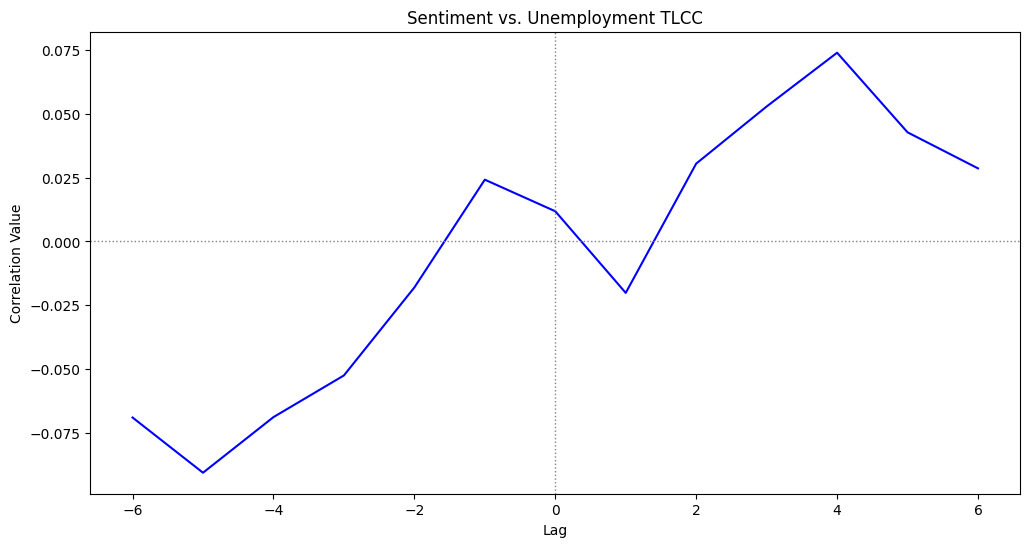

In [34]:
temp_df = all_feature_data[['UNRATE_MoM_diff']].copy()

for lag in range(-6, 7):
    col_name = f'sent_lag_{lag}'
    temp_df[col_name] = all_feature_data['Neutrality_Ratio_30day_EMA'].shift(lag)

temp_df = temp_df.dropna()

correlations = []
for lag in range(-6, 7):
    col_name = f'sent_lag_{lag}'
    corr_value = temp_df[col_name].corr(temp_df['UNRATE_MoM_diff'])
    correlations.append([lag, corr_value])
df = pd.DataFrame(correlations, columns = ['Lag', 'Correlation Value']) 

from matplotlib import pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Lag'], df['Correlation Value'], 
         label='Sentiment vs. Unemployment TLCC', color='blue')
plt.axhline(y=0, color='grey', linestyle=':', linewidth=1, label="Neutral Correlation")
plt.axvline(x=0, color='grey', linestyle=':', linewidth=1, label="Neutral Lag")
plt.title('Sentiment vs. Unemployment TLCC')
plt.xlabel('Lag')
plt.ylabel('Correlation Value')

The peak occurs at around a lag of 4 base on the following two factors:
- UNRATE_MoM_diff (Hard Data): Did the unemployment rate go up or down this month?
- Neutrality_Ratio_30day_EMA (Soft Data): Are the financial news headlines leaning positive or negative this month?

So based on this graph: Sentiment from 4 months ago is the best match for the Unemployment changes happening today.

To directly answers your Phase 3 objective: Does the crowd anticipate the data, or react to it?
- A peak at Lag = +4 provides quantitative proof that Sentiment LEADS the hard data by 4 months.

But we have to note that **Correlation of continuous signals (movements) is NOT the same as predicting a binary event (a recession).** 